In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import seaborn as sns
from wordcloud import WordCloud
import logging
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers

In [3]:
!pip install mediapipe

In [4]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.0

Found existing installation: protobuf 4.25.6
Uninstalling protobuf-4.25.6:
  Successfully uninstalled protobuf-4.25.6
  Using cached protobuf-3.20.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (698 bytes)
Using cached protobuf-3.20.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.10 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 3.20.0 which is incompatible.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
google-cloud-aiplatform 1.74.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have p

In [5]:
!pip uninstall -y mediapipe
!pip install mediapipe  

Found existing installation: mediapipe 0.10.21
Uninstalling mediapipe-0.10.21:
  Successfully uninstalled mediapipe-0.10.21
  Using cached mediapipe-0.10.21-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached protobuf-4.25.6-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached mediapipe-0.10.21-cp310-cp310-manylinux_2_28_x86_64.whl (35.6 MB)
Using cached protobuf-4.25.6-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.0
    Uninstalling protobuf-3.20.0:
      Successfully uninstalled protobuf-3.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 4.25.6 which is incompatible.
google-cloud-bigtable 2.27

In [6]:
import mediapipe as mp

In [7]:
# import os
# dataset_path = '/kaggle/input/asl-citizen/ASL_Citizen'
# for root, dirs, files in os.walk(dataset_path):
#     print(f"Root: {root}")
#     print(f"Dirs: {dirs}")
#     print(f"Files (first 5): {files[:5]}")
#     print(f"Total files: {len(files)}")

In [8]:
base_path = '/kaggle/input/asl-citizen/ASL_Citizen'
video_dir = os.path.join(base_path, 'videos')
splits_dir = os.path.join(base_path, 'splits')

In [9]:
seed=random.seed(1024)
print(random.randint(7,12))

7


# Data Exploration

In [10]:
import pandas as pd
train = pd.read_csv('/kaggle/input/asl-citizen/ASL_Citizen/splits/train.csv')
test = pd.read_csv('/kaggle/input/asl-citizen/ASL_Citizen/splits/test.csv')
val = pd.read_csv('/kaggle/input/asl-citizen/ASL_Citizen/splits/val.csv')

In [11]:
train.sample(20)

,Participant ID,Video file,Gloss,ASL-LEX Code
35143,P28,52182646297618-TOMORROW.mp4,TOMORROW,F_02_040
39184,P52,05375377658392799-seedRACE.mp4,RACE,F_02_075
11727,P16,7233773248551201-PRECIOUS.mp4,PRECIOUS,H_02_071
25216,P27,2575676745232838-PSYCHOLOGY.mp4,PSYCHOLOGY,F_02_074
9061,P14,4932430882992249-RHINO.mp4,RHINO3,D_03_016
12630,P16,43591635506446313-CHEW 4.mp4,CHEW4,K_03_094
5766,P37,764702091809278-BUTTER.mp4,BUTTER,A_01_034
24311,P31,7477807074500644-TRAIN.mp4,TRAIN,B_03_003
18645,P10,5166467740266834-ANYONE.mp4,ANYONE,H_01_059
33640,P11,28342765697805894-GRAY.mp4,GRAY,F_01_080


In [12]:
test.sample(7)

,Participant ID,Video file,Gloss,ASL-LEX Code
25422,P17,850080984855919-CROSS 2.mp4,CROSS3,H_01_007
28007,P22,32750601321146666-PLAY.mp4,PLAY,C_01_066
9457,P15,4052019533852902-VALUE.mp4,VALUE,H_03_085
20252,P49,6818453048614443-SHAKE 2.mp4,SHAKE2,F_03_048
13455,P18,00789791441529486-ANY.mp4,ANY,G_01_016
26811,P9,3282029278352854-EXPERIMENT.mp4,EXPERIMENT,H_03_002
1747,P35,4165366764363416-BRAIDS.mp4,BRAIDS,K_03_125


In [13]:
test.sample(7)

,Participant ID,Video file,Gloss,ASL-LEX Code
648,P42,7986823009115653-PEACH 2.mp4,PEACH2,K_02_087
31834,P17,42511021464845977-CHASE.mp4,CHASE,F_03_017
31217,P17,11567823805090094-PARENTS.mp4,PARENTS,B_03_044
2873,P35,7390474001199401-RING.mp4,RING,A_03_053
4068,P42,37422096239829483-CLICK.mp4,CLICK,G_01_047
605,P42,6970453966263672-JELLYFISH.mp4,JELLYFISH,G_03_049
19362,P48,07524718021503718-HEADACHE.mp4,HEADACHE,B_01_027


In [14]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40154 entries, 0 to 40153
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Participant ID  40154 non-null  object
 1   Video file      40154 non-null  object
 2   Gloss           40154 non-null  object
 3   ASL-LEX Code    40066 non-null  object
dtypes: object(4)
memory usage: 1.2+ MB
None


In [15]:
train.isnull().sum()

Participant ID     0
Video file         0
Gloss              0
ASL-LEX Code      88
dtype: int64

In [16]:
print("trainig set has : ", train.shape[0], " rows")
print("val set has : ", val.shape[0], " rows")
print("testing set has : ", test.shape[0], " rows")

trainig set has :  40154  rows
val set has :  10304  rows
testing set has :  32941  rows


In [17]:
#changing column names to follow convention
train.rename(columns={'Participant ID' : 'p_id',
                   'Video file': 'video_id',
                   'Gloss' : 'gloss',
                   'ASL-LEX Code' : 'code'
                  }, inplace=True)
#changing column names to follow convention
test.rename(columns={'Participant ID' : 'p_id',
                   'Video file': 'video_id',
                   'Gloss' : 'gloss',
                   'ASL-LEX Code' : 'code'
                  }, inplace=True)
#changing column names to follow convention
val.rename(columns={'Participant ID' : 'p_id',
                   'Video file': 'video_id',
                   'Gloss' : 'gloss',
                   'ASL-LEX Code' : 'code'
                  }, inplace=True)

In [18]:
train.columns

Index(['p_id', 'video_id', 'gloss', 'code'], dtype='object')

In [19]:
#checking for videos
video_files = os.listdir(video_dir)
sample_vid = train.iloc[34:50]['video_id']
for vid in sample_vid:
    if vid in video_files:
        print("found")
    else:
        print("Does not exist")

found
found
found
found
found
found
found
found
found
found
found
found
found
found
found
found


In [20]:
unique_glosses = len(train['gloss'].unique())
print(f"total glosses: {len(train['gloss'])} \nunique: {unique_glosses} ")

total glosses: 40154 
unique: 2731 


In [21]:
signers = len(train['p_id'].unique())
print(f"Number of signers: {signers} ")

Number of signers: 35 


In [22]:
#which signer recorded how many videos?
p_id_counts = train['p_id'].value_counts()
p_id_counts

p_id
P33    3000
P11    3000
P27    2999
P40    2998
P50    2991
P37    2989
P31    2971
P29    2933
P52    2728
P16    2149
P14    1755
P51    1502
P30    1490
P7     1195
P23    1000
P43     901
P4      444
P34     425
P36     380
P46     374
P28     322
P20     319
P2      221
P25     144
P10     141
P24     125
P38     120
P8      113
P3      109
P1      104
P32     102
P45      58
P44      42
P41       7
P19       3
Name: count, dtype: int64

In [23]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {'frames': frames, 'fps': fps, 'width': width, 'height': height}

In [24]:
# meta_df = pd.DataFrame()

# # Wrap 'train['video_id']' with tqdm to display progress
# for vid in tqdm(train['video_id'], desc="Processing Videos", unit="video"):
#     path = os.path.join(video_dir, vid)
#     info = get_video_info(path)
    
#     if info:
#         meta_df = pd.concat([meta_df, pd.DataFrame([{
#             'video_id': vid,
#             'frames': info['frames'],
#             'fps': info['fps'],
#             'width': info['width'],
#             'height': info['height']
#         }])], ignore_index=True)

# print(meta_df)


In [25]:
# meta_df['duration'] = (meta_df['frames'] / meta_df['fps']).round(2)

In [26]:
meta_df = pd.read_csv("/kaggle/input/asl-video-meta-data/video_metadata (1).csv")

In [27]:
meta_df.head()

,video_id,frames,fps,width,height,duration
0,15890366051589533-APPLE.mp4,71,29.919933,640,480,2.37
1,35618482303951104-IMPOSSIBLE.mp4,76,29.968454,640,480,2.54
2,6958143575951994-PARK.mp4,87,30.000000,640,480,2.90
3,8006032738002744-SOCCER 2.mp4,112,30.002679,640,480,3.73
4,37542279833186454-STINK.mp4,87,30.000000,640,480,2.90


In [28]:
meta_df.to_csv("/kaggle/working/video_metadata.csv", index=False)
print("File saved to: /kaggle/working/video_metadata.csv")

File saved to: /kaggle/working/video_metadata.csv


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


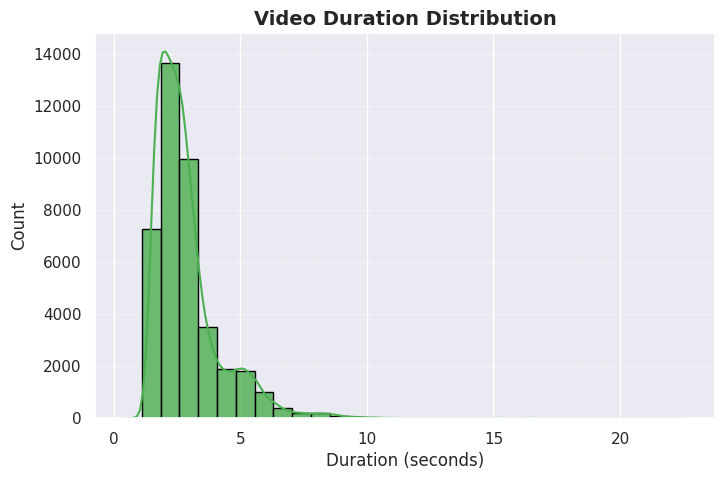

In [29]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")  # Stylish background
sns.histplot(meta_df['duration'], bins=30, kde=True, 
             color='#4CAF50', edgecolor='black', alpha=0.8)
plt.title("Video Duration Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Duration (seconds)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


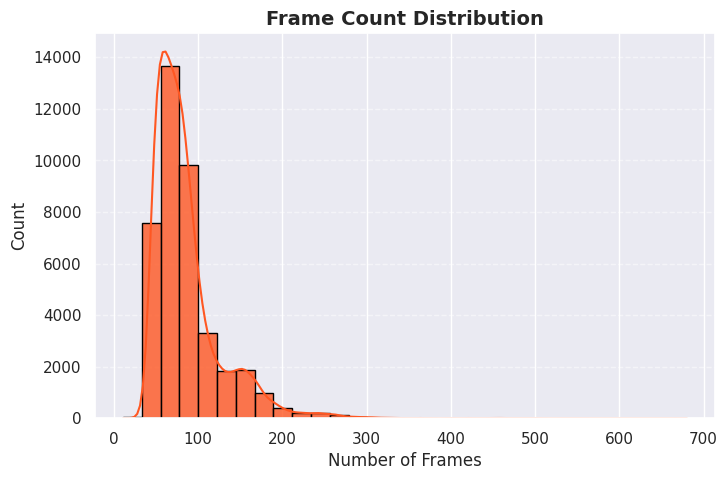

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(meta_df['frames'], bins=30, kde=True, 
             color='#FF5722', edgecolor='black', alpha=0.8)
plt.title("Frame Count Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Frames", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
gloss_text = ' '.join(train['gloss'].values)

wordcloud = WordCloud(
    width=800, height=400, 
    background_color='black', 
    colormap='cool', 
    max_words=100,     
    contour_color='white', contour_width=2
).generate(gloss_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") 
plt.title("Gloss Word Cloud (Frequency-Based)", fontsize=16, fontweight='bold')
plt.show()

Plotting a Gloss vs Duration chart can reveal important insights, such as:

1. Which glosses tend to have longer or shorter durations.
2. Potential outliers (e.g., unusually long or short signs).
3. Patterns in sign complexity — longer durations might indicate complex signs or gestures.

In [32]:
train_n_meta = pd.merge(train, meta_df, on='video_id', how='inner')

In [33]:
train_n_meta.head()

,p_id,video_id,gloss,code,frames,fps,width,height,duration
0,P1,15890366051589533-APPLE.mp4,APPLE,A_03_054,71,29.919933,640,480,2.37
1,P1,35618482303951104-IMPOSSIBLE.mp4,IMPOSSIBLE,B_01_032,76,29.968454,640,480,2.54
2,P1,6958143575951994-PARK.mp4,PARK,E_03_028,87,30.000000,640,480,2.90
3,P1,8006032738002744-SOCCER 2.mp4,SOCCER2,F_03_032,112,30.002679,640,480,3.73
4,P1,37542279833186454-STINK.mp4,STINK,H_01_064,87,30.000000,640,480,2.90


# keypoints extraction test

In [34]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5)

sample_video_path = os.path.join(video_dir, train_n_meta['video_id'].iloc[40])
output_video_path = 'processed_video.mp4'

cap = cv2.VideoCapture(sample_video_path)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, cap.get(cv2.CAP_PROP_FPS), 
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    out.write(frame) 

cap.release()
out.release()

print(f"Processed video saved as: {output_video_path}")

Processed video saved as: processed_video.mp4


In [ ]:
cap = cv2.VideoCapture(output_video_path)

frame_interval = 10   # Display every 10th frame
frames_to_show = 15   # Number of frames to display

plt.figure(figsize=(18, 8))  # Increased width to accommodate 15 frames

# Display frames in 3 rows × 5 columns for better organization
rows, cols = 3, 5

for i in range(frames_to_show):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
    ret, frame = cap.read()

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {i * frame_interval}", fontsize=9)
        plt.axis('off')

plt.suptitle("Sample Processed Frames with Hand Landmarks", fontsize=16, fontweight='bold')
plt.tight_layout(pad=1.5)  # Balanced spacing for improved clarity
plt.show()

cap.release()


# Video Preprocessing

1. Resize them to a standard size (e.g., 224x224) for ML compatibility.
2. Save the results efficiently (e.g., as NumPy arrays) in Kaggle’s working directory.

In [37]:
combined_df = pd.concat([train, test, val]).reset_index(drop=True)
gloss_counts = combined_df['gloss'].value_counts()
gloss_counts

gloss
DOG1           45
BASKETBALL1    44
WHATFOR1       43
BELT1          40
PARTY1         39
               ..
DEMAND2        22
GUESS2         22
SHAVE2         22
LETTUCE2       21
BEE2           21
Name: count, Length: 2731, dtype: int64

In [38]:
# Identify glosses with ≥ 38 videos
selected_glosses = gloss_counts[gloss_counts >= 39].index
selected_glosses.size

23

In [39]:
# Filter videos with selected glosses
filtered_videos = combined_df[combined_df['gloss'].isin(selected_glosses)]

In [40]:
# Sample ~600-800 videos
subset_size = min(len(filtered_videos), 900) 
subset_videos = filtered_videos.sample(n=subset_size, random_state=42).reset_index(drop=True)
subset_size

900

In [41]:
train_subset, temp_subset = train_test_split(subset_videos, test_size=0.3, random_state=42)
test_subset, val_subset = train_test_split(temp_subset, test_size=1/3, random_state=42)

In [42]:
print("trainig sub set has : ", train_subset.shape[0], " rows")
print("val sub set has : ", val_subset.shape[0], " rows")
print("testing sub set has : ", test_subset.shape[0], " rows")

trainig sub set has :  630  rows
val sub set has :  90  rows
testing sub set has :  180  rows


In [43]:
# Display distribution details
print("Training Set Distribution:\n", train_subset['gloss'].value_counts())
print("\nTesting Set Distribution:\n", test_subset['gloss'].value_counts())
print("\nValidation Set Distribution:\n", val_subset['gloss'].value_counts())

Training Set Distribution:
 gloss
DOG1             33
BITE1            33
BASKETBALL1      31
DEAF1            30
PARTY1           30
DARK1            30
BEE1             30
FOREIGNER1       29
SHAVE1           29
HOSPITAL1        28
PATIENT2         28
ROCKINGCHAIR1    27
MECHANIC1        27
WHATFOR1         27
BELT1            26
FINE1            26
NIGHT1           26
CHRISTMAS1       26
BREAKFAST1       24
DEMAND1          24
MOVIE1           23
EAT1             22
ELEVATOR1        21
Name: count, dtype: int64

Testing Set Distribution:
 gloss
BREAKFAST1       12
ELEVATOR1        11
MOVIE1           11
EAT1             10
DOG1             10
BASKETBALL1      10
WHATFOR1         10
ROCKINGCHAIR1     9
BELT1             9
FINE1             9
HOSPITAL1         8
NIGHT1            8
DEAF1             8
MECHANIC1         8
DEMAND1           7
BEE1              6
FOREIGNER1        6
BITE1             6
SHAVE1            5
PARTY1            5
DARK1             4
CHRISTMAS1        4
PATIEN

# Loading Subsets

In [113]:
train_subset.to_csv('train_subset.csv', index=False)
test_subset.to_csv('test_subset.csv', index=False)
val_subset.to_csv('val_subset.csv', index=False)

In [114]:
import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger()

In [115]:
# MediaPipe setup—hands only
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5)

# Keypoints Extraction

In [116]:
def get_keypoints(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    hand_results = hands.process(frame_rgb) 
    keypoints = np.zeros((42 * 3,))
    
    if hand_results.multi_hand_landmarks:
        for i, hand_landmarks in enumerate(hand_results.multi_hand_landmarks[:2]): 
            for j, lm in enumerate(hand_landmarks.landmark):
                keypoints[i * 21 * 3 + j * 3:i * 21 * 3 + j * 3 + 3] = [lm.x, lm.y, lm.z]
    
    return keypoints

In [117]:
def extract_keypoint_frames(video_path, target_frames=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None, None, f"Failed to open {video_path}"

    all_frames = []
    all_keypoints = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame is None or frame.size == 0:
            break

        if len(frame.shape) == 2:
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

        frame = cv2.resize(frame, (224, 224))
        all_frames.append(frame)
        all_keypoints.append(get_keypoints(frame))
    cap.release()

    if len(all_frames) < target_frames:
        return None, None, f"Too few frames in {video_path}"

    all_keypoints = np.array(all_keypoints)  

    # Adaptive sliding window logic
    total_frames = len(all_frames)
    base_window_size = total_frames // target_frames  # Base size ~10 frames
    key_indices = []
    key_keypoints = []
    frame_idx = 0

    while len(key_indices) < target_frames and frame_idx < total_frames - 1:
        # Define window
        window_start = frame_idx
        window_end = min(window_start + base_window_size, total_frames)
        window_keypoints = all_keypoints[window_start:window_end]

        # Calculate movement in window
        if len(window_keypoints) > 1:
            distances = [np.linalg.norm(window_keypoints[i] - window_keypoints[i-1]) 
                         for i in range(1, len(window_keypoints))]
            max_motion_idx = np.argmax(distances) + 1 if distances else 0
            motion = distances[max_motion_idx - 1] if distances else 0
        else:
            max_motion_idx = 0
            motion = 0

        # Adaptive adjustment: stretch if no gesture, shrink if lots of gesture
        if motion < 0.05:  # Minimal movement—stretch window
            window_end = min(window_end + base_window_size // 2, total_frames)
        elif motion > 0.2:  # High movement—shrink window
            window_end = window_start + max(1, base_window_size // 2)

        # Pick frame with max movement
        selected_idx = window_start + max_motion_idx
        key_indices.append(selected_idx)
        key_keypoints.append(all_keypoints[selected_idx])
        frame_idx = window_end  # Slide to next window

    # Pad with last frames if we didn’t get 10
    while len(key_indices) < target_frames:
        last_idx = total_frames - (target_frames - len(key_indices))
        if last_idx not in key_indices:
            key_indices.append(last_idx)
            key_keypoints.append(all_keypoints[last_idx])

    # Collect key frames and keypoints
    key_frames = [all_frames[i] for i in key_indices]
    key_keypoints = np.array(key_keypoints)  # Shape: (10, 165)

    return np.array(key_frames), key_keypoints, None

In [118]:
output_dir = '/kaggle/working/keypoint_frames/'
os.makedirs(output_dir, exist_ok=True)

In [119]:
def process_videos(subset, video_dir, output_dir, target_frames=10):
    processed_data = {}

    for idx, row in tqdm(subset.iterrows(), total=len(subset)):
        video_id = row['video_id']
        gloss = row.get('gloss', 'Unknown')
        video_path = os.path.join(video_dir, video_id)

        key_frames, key_keypoints, error = extract_keypoint_frames(video_path, target_frames=target_frames)
        if error:
            print("got error")
            logger.warning(error)
            continue

        frame_path = os.path.join(output_dir, f"{video_id}_keyframes.npy")
        keypoint_path = os.path.join(output_dir, f"{video_id}_keypoints.npy")
        np.save(frame_path, key_frames)
        np.save(keypoint_path, key_keypoints)

        processed_data[video_id] = {
            'gloss': gloss,
            'frame_count': len(key_frames),
            'frame_path': frame_path,
            'keypoint_path': keypoint_path
        }

        if idx % 100 == 0:
            logger.info(f"Processed {idx} videos so far...")

        logger.info(f"Processed {video_id}: {len(key_frames)} key frames")
        print(f"Processed {video_id}: {len(key_frames)} key frames")

    # Save metadata to Excel
    metadata_df = pd.DataFrame.from_dict(processed_data, orient='index')
    metadata_df.to_excel(os.path.join(output_dir, 'keypoint_frames_metadata.xlsx'), index_label='video_id')
    logger.info(f"Metadata saved for {len(processed_data)} videos")
    # print(metadata_df)
    return metadata_df

In [121]:
def create_small_subsets(graphs_metadata_path):
    import pandas as pd
    import numpy as np

    # Load the metadata
    df = pd.read_csv(graphs_metadata_path)
    print(f"Loaded {len(df)} graphs from {graphs_metadata_path}")

    # Define the sampling counts for each class
    sampling_counts = {
        "DOG1": 16, "BITE1": 16, "BASKETBALL1": 15, "DEAF1": 15, "PARTY1": 15,
        "DARK1": 15, "BEE1": 15, "FOREIGNER1": 14, "SHAVE1": 14, "HOSPITAL1": 14,
        "PATIENT2": 14, "ROCKINGCHAIR1": 13, "MECHANIC1": 13, "WHATFOR1": 13,
        "BELT1": 13, "FINE1": 13, "NIGHT1": 13, "CHRISTMAS1": 13, "BREAKFAST1": 12,
        "DEMAND1": 12, "MOVIE1": 11, "EAT1": 10, "ELEVATOR1": 9
    }

    # Sample videos for each class
    sampled_dfs = []
    for gloss, count in sampling_counts.items():
        class_df = df[df['gloss'] == gloss]
        if len(class_df) < count:
            print(f"Warning: Not enough samples for {gloss}. Requested {count}, but only {len(class_df)} available.")
            sampled_df = class_df
        else:
            sampled_df = class_df.sample(n=count, random_state=42)
        sampled_dfs.append(sampled_df)

    # Combine sampled data
    small_df = pd.concat(sampled_dfs, ignore_index=True)
    print(f"Sampled {len(small_df)} videos for small subset")

    # Define split counts
    split_counts = {
        "DOG1": {"train": 11, "test": 2, "val": 3},
        "BITE1": {"train": 11, "test": 2, "val": 3},
        "BASKETBALL1": {"train": 11, "test": 2, "val": 2},
        "DEAF1": {"train": 11, "test": 2, "val": 2},
        "PARTY1": {"train": 11, "test": 2, "val": 2},
        "DARK1": {"train": 11, "test": 2, "val": 2},
        "BEE1": {"train": 11, "test": 2, "val": 2},
        "FOREIGNER1": {"train": 10, "test": 2, "val": 2},
        "SHAVE1": {"train": 10, "test": 2, "val": 2},
        "HOSPITAL1": {"train": 10, "test": 2, "val": 2},
        "PATIENT2": {"train": 10, "test": 2, "val": 2},
        "ROCKINGCHAIR1": {"train": 9, "test": 2, "val": 2},
        "MECHANIC1": {"train": 9, "test": 2, "val": 2},
        "WHATFOR1": {"train": 9, "test": 2, "val": 2},
        "BELT1": {"train": 9, "test": 2, "val": 2},
        "FINE1": {"train": 9, "test": 2, "val": 2},
        "NIGHT1": {"train": 9, "test": 2, "val": 2},
        "CHRISTMAS1": {"train": 9, "test": 2, "val": 2},
        "BREAKFAST1": {"train": 8, "test": 2, "val": 2},
        "DEMAND1": {"train": 8, "test": 2, "val": 2},
        "MOVIE1": {"train": 8, "test": 2, "val": 1},
        "EAT1": {"train": 7, "test": 1, "val": 2},
        "ELEVATOR1": {"train": 6, "test": 1, "val": 2}
    }

    # Split into train, test, val
    train_dfs, test_dfs, val_dfs = [], [], []
    for gloss, counts in split_counts.items():
        class_df = small_df[small_df['gloss'] == gloss]
        class_df = class_df.sample(frac=1, random_state=42)  # Shuffle
        train_count, test_count, val_count = counts['train'], counts['test'], counts['val']
        
        train_df = class_df[:train_count]
        test_df = class_df[train_count:train_count + test_count]
        val_df = class_df[train_count + test_count:train_count + test_count + val_count]
        
        train_dfs.append(train_df)
        test_dfs.append(test_df)
        val_dfs.append(val_df)

    # Combine splits
    train_small = pd.concat(train_dfs, ignore_index=True)
    test_small = pd.concat(test_dfs, ignore_index=True)
    val_small = pd.concat(val_dfs, ignore_index=True)

    print(f"Created train_small: {len(train_small)} videos")
    print(f"Created test_small: {len(test_small)} videos")
    print(f"Created val_small: {len(val_small)} videos")

    # Save to CSV
    train_small.to_csv("/kaggle/working/graphs_tf/train_small.csv", index=False)
    test_small.to_csv("/kaggle/working/graphs_tf/test_small.csv", index=False)
    val_small.to_csv("/kaggle/working/graphs_tf/val_small.csv", index=False)

    return train_small, test_small, val_small

# Run
train_small, test_small, val_small = create_small_subsets("/kaggle/input/data-subset/train_subset.csv")

Loaded 630 graphs from /kaggle/input/data-subset/train_subset.csv
Sampled 308 videos for small subset
Created train_small: 217 videos
Created test_small: 44 videos
Created val_small: 47 videos


In [123]:
test_small = pd.read_csv("/kaggle/input/smallsets/test_small.csv")
train_small = pd.read_csv("/kaggle/input/smallsets/train_small.csv")
val_small = pd.read_csv("/kaggle/input/smallsets/val_small.csv")

In [145]:
metadata_df = process_videos(train_small,
               video_dir,
               output_dir, 
               target_frames=10)

  0%|          | 0/217 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [146]:
metadata_df.shape

(217, 4)

In [147]:
metadata_df.head(3)

,gloss,frame_count,frame_path,keypoint_path
6099821247676596-DOG.mp4,DOG1,10,/kaggle/working/keypoint_frames/60998212476765...,/kaggle/working/keypoint_frames/60998212476765...
5208069588201667-DOG.mp4,DOG1,10,/kaggle/working/keypoint_frames/52080695882016...,/kaggle/working/keypoint_frames/52080695882016...
5202332177126394-DOG.mp4,DOG1,10,/kaggle/working/keypoint_frames/52023321771263...,/kaggle/working/keypoint_frames/52023321771263...


In [148]:
samp_key = np.load(metadata_df['keypoint_path'][6])
samp_key.shape

<ipython-input-148-4c66e1d6f2b7>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



(10, 126)

In [149]:
samp_key.shape

(10, 126)

In [150]:
metadata_df["frame_path"][0]

<ipython-input-150-59ccf09b67e8>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



'/kaggle/working/keypoint_frames/6099821247676596-DOG.mp4_keyframes.npy'

In [151]:
frames=np.load(metadata_df["frame_path"][8])
keypoints=np.load(metadata_df["keypoint_path"][8])

<ipython-input-151-3498336f88c1>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-151-3498336f88c1>:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Frame shape: (10, 224, 224, 3)
Keypoints shape: (10, 42, 2)
Keypoints min/max (raw): 0.0 0.9375203847885132
Scaled keypoints from normalized (0-1) to pixel coordinates
Keypoints min/max (scaled): 0.0 210.00456619262695
Sample keypoints (first frame): [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
Frame 0: 42 valid keypoints plotted
Frame 1: 42 valid keypoints plotted
Frame 2: 42 valid keypoints plotted
Frame 3: 42 valid keypoints plotted
Frame 4: 42 valid keypoints plotted
Frame 5: 42 valid keypoints plotted
Frame 6: 42 valid keypoints plotted
Frame 7: 42 valid keypoints plotted
Frame 8: 42 valid keypoints plotted
Frame 9: 42 valid keypoints plotted


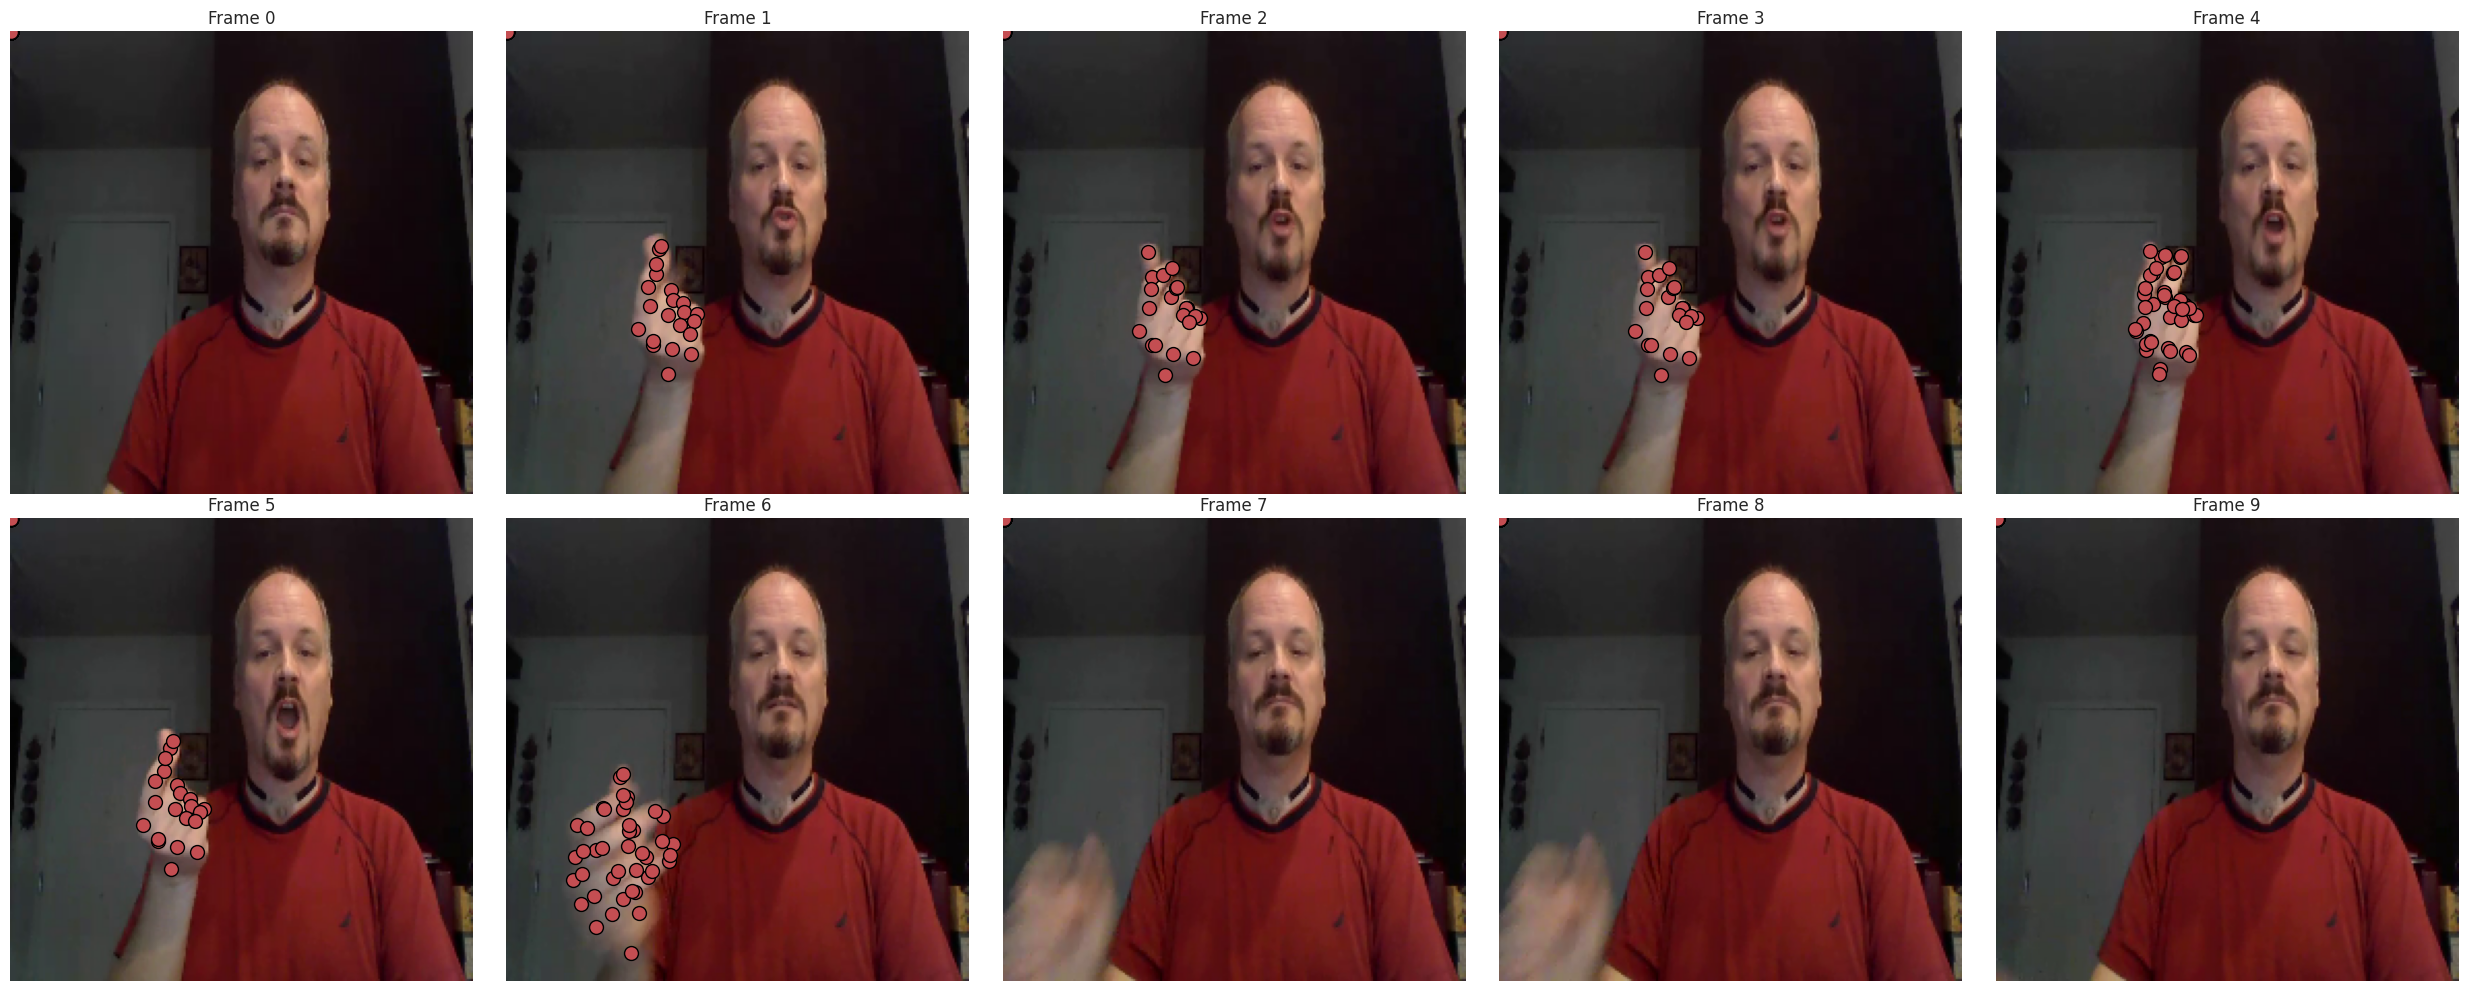

In [152]:
def plot_keypoints_on_frames(frames, keypoints, output_path=None):
    num_frames = frames.shape[0]
    
    if keypoints.shape[0] != num_frames:
        print("Number of frames in 'frames' and 'keypoints' are unequal!")
    
    # Handle keypoints reshaping
    if keypoints.ndim == 2 and keypoints.shape[1] == 126:
        keypoints = keypoints.reshape(num_frames, 42, 3)[:, :, :2]
    elif keypoints.ndim == 3 and keypoints.shape[2] == 3:
        keypoints = keypoints[:, :, :2]
    elif keypoints.ndim == 3 and keypoints.shape[2] == 2:
        pass
    else:
        raise ValueError(f"Unsupported keypoints shape: {keypoints.shape}")

    # Debug info
    print("Frame shape:", frames.shape)
    print("Keypoints shape:", keypoints.shape)
    print("Keypoints min/max (raw):", keypoints.min(), keypoints.max())

    # Scale keypoints
    height, width = frames.shape[1], frames.shape[2]
    keypoints_scaled = keypoints.copy()
    
    # Improved scaling logic
    max_val = keypoints.max()
    if max_val <= 2.0:  # Assume normalized if max is reasonably close to 1
        keypoints_scaled[:, :, 0] *= width
        keypoints_scaled[:, :, 1] *= height
        print("Scaled keypoints from normalized (0-1) to pixel coordinates")
    else:
        print("Keypoints assumed to be in pixel coordinates")

    print("Keypoints min/max (scaled):", keypoints_scaled.min(), keypoints_scaled.max())
    print("Sample keypoints (first frame):", keypoints_scaled[0][:5])

    # Video writer setup
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, 30.0, (width, height))

    # Plot setup
    rows = 2
    cols = (num_frames + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten()

    for i in range(num_frames):
        frame = frames[i].copy()
        
        # Ensure correct color format
        if frame.shape[-1] == 3:
            if frame.max() > 1 and frame.dtype == np.uint8:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            elif frame.max() <= 1:
                frame = (frame * 255).astype(np.uint8)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame_keypoints = keypoints_scaled[i]
        
        # Video output
        if output_path:
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            for x, y in frame_keypoints:
                x, y = int(x), int(y)
                if 0 <= x < width and 0 <= y < height:
                    cv2.circle(frame_bgr, (x, y), 5, (0, 255, 0), -1)
            out.write(frame_bgr)

        # Plotting
        axes[i].imshow(frame)
        valid_points = 0
        for x, y in frame_keypoints:
            if 0 <= x < width and 0 <= y < height:
                # Use larger, more visible markers
                axes[i].plot(x, y, 'ro', markersize=10, markeredgecolor='black', markeredgewidth=1)
                valid_points += 1
            else:
                print(f"Frame {i}: Out of bounds keypoint - x: {x}, y: {y}")
        print(f"Frame {i}: {valid_points} valid keypoints plotted")
        axes[i].axis('off')
        axes[i].set_title(f'Frame {i}')

    for j in range(num_frames, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    if output_path:
        out.release()


plot_keypoints_on_frames(frames, keypoints)

# Graph Modelling

In [153]:
graph_dir = '/kaggle/working/graphs_tf/'
os.makedirs(graph_dir, exist_ok=True)

In [154]:
def get_spatial_edges():
    hand_connections = [
        (0, 1), (0, 5), (0, 9), (0, 13), (0, 17), #wrist to fingers
        (1, 2), (2, 3), (3, 4),                   #thumb    
        (5, 6), (6, 7), (7, 8),                   #index finger
        (9, 10), (10, 11), (11, 12),              #middle finger
        (13, 14), (14, 15), (15, 16),             #ring finger
        (17, 18), (18, 19), (19, 20)              #pinky finger
    ]
    edge_list = []
    for hand_offset in [0, 21]:
        for src, dst in hand_connections:
            edge_list.append([src + hand_offset, dst + hand_offset])
    return np.array(edge_list)  # (40, 2)

In [155]:
def build_spatio_temporal_graph(video_id, keypoints):
    num_frames = keypoints.shape[0]  
    num_nodes_per_frame = 42
    
    features = keypoints.reshape(num_frames, num_nodes_per_frame, 3)  # (10, 42, 3)
    features = tf.convert_to_tensor(features.reshape(-1, 3), dtype=tf.float32)  # (420, 3)
    
    spatial_edges = get_spatial_edges() 
    spatial_edges_per_frame = [spatial_edges + (t * num_nodes_per_frame) for t in range(num_frames)]
    spatial_edges = np.concatenate(spatial_edges_per_frame, axis=0)  # (400, 2)
    
    temporal_edges = []
    for t in range(num_frames - 1):  # 9 transitions
        for node in range(num_nodes_per_frame):
            src = t * num_nodes_per_frame + node
            dst = (t + 1) * num_nodes_per_frame + node
            temporal_edges.append([src, dst])
    temporal_edges = np.array(temporal_edges)  # (378, 2)
    
    edge_index = np.concatenate([spatial_edges, temporal_edges], axis=0)  # (778, 2)
    edge_index = tf.convert_to_tensor(edge_index, dtype=tf.int64)
    
    graph = {
        'features': features,  # (420, 3)
        'edge_index': edge_index,  # (778, 2)
        'num_nodes': num_frames * num_nodes_per_frame  # 420
    }
    logger.info(f"Graph for {video_id}: {graph['num_nodes']} nodes, {edge_index.shape[0]} edges")
    return graph

In [156]:
def process_graphs_to_dataset(train_subset):
    gloss_map = dict(zip(train_subset['video_id'].astype(str), train_subset['gloss']))
    
    graphs = {}
    for video_id in tqdm(train_subset['video_id'].astype(str), desc="Building graphs"):
        video_path = os.path.join(video_dir, video_id)
        _, keypoints, error = extract_keypoint_frames(video_path, target_frames=10)
        if error:
            logger.warning(error)
            continue
        graph = build_spatio_temporal_graph(video_id, keypoints)
        graph['gloss'] = gloss_map.get(video_id, 'unknown')
        graph_path = os.path.join(graph_dir, f"{video_id}_graph.npz")
        np.savez(graph_path, features=graph['features'].numpy(), edge_index=graph['edge_index'].numpy(), gloss=graph['gloss'])
        graphs[video_id] = graph_path
    
    graph_metadata = pd.DataFrame.from_dict(graphs, orient='index', columns=['graph_path'])
    graph_metadata.to_csv(os.path.join(graph_dir, 'graphs_metadata.csv'))
    
    def graph_generator():
        for video_id, graph_path in graphs.items():
            data = np.load(graph_path)
            yield {
                'features': tf.convert_to_tensor(data['features'], dtype=tf.float32),
                'edge_index': tf.convert_to_tensor(data['edge_index'], dtype=tf.int64),
                'gloss': tf.convert_to_tensor(data['gloss'], dtype=tf.string)
            }
    
    dataset = tf.data.Dataset.from_generator(
        graph_generator,
        output_signature={
            'features': tf.TensorSpec(shape=(420, 3), dtype=tf.float32),
            'edge_index': tf.TensorSpec(shape=(778, 2), dtype=tf.int64),
            'gloss': tf.TensorSpec(shape=(), dtype=tf.string)
        }
    ).batch(1)
    return dataset

In [157]:
dataset = process_graphs_to_dataset(train_small)
print("done")

Building graphs: 100%|██████████| 217/217 [08:06<00:00,  2.24s/it]

done


In [163]:
for graph in dataset.take(1):
    print("Features shape:", graph['features'].shape)  # (1, 420, 3)
    print("Edge index shape:", graph['edge_index'].shape)  # (1, 778, 2)
    print("Gloss:", graph['gloss'])

Features shape: (1, 420, 3)
Edge index shape: (1, 778, 2)
Gloss: tf.Tensor([b'DOG1'], shape=(1,), dtype=string)


In [164]:
dataset

<_BatchDataset element_spec={'features': TensorSpec(shape=(None, 420, 3), dtype=tf.float32, name=None), 'edge_index': TensorSpec(shape=(None, 778, 2), dtype=tf.int64, name=None), 'gloss': TensorSpec(shape=(None,), dtype=tf.string, name=None)}>

Visualizing graphs from dataset...
Graph for gloss: b'MECHANIC1'


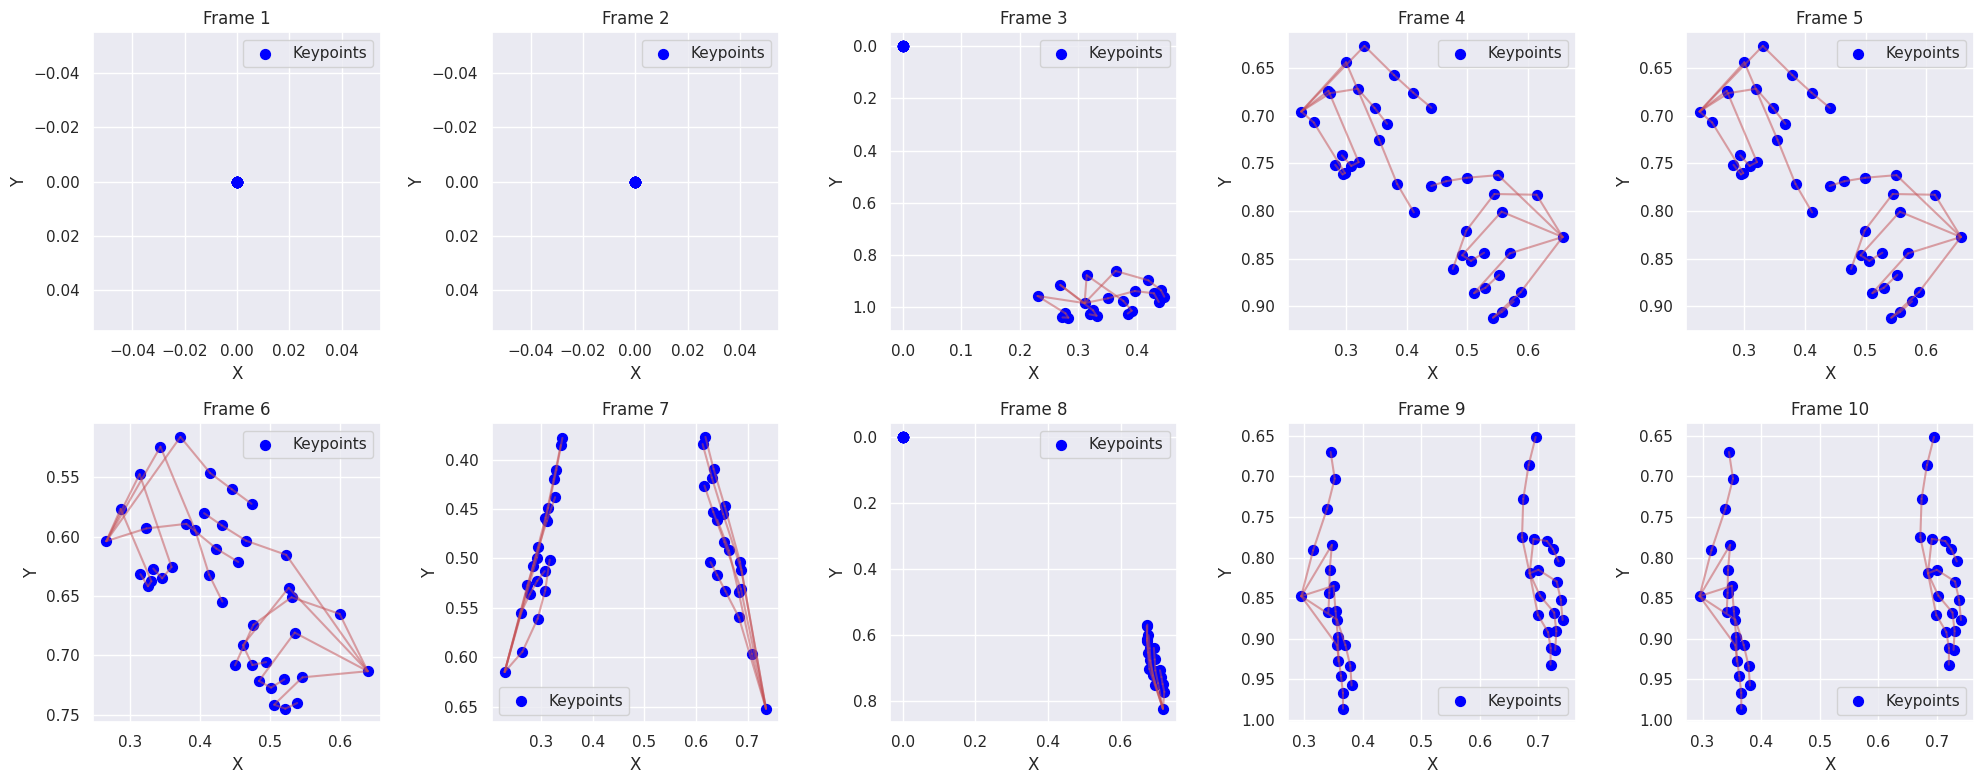

Visualization complete!


In [65]:
# Visualize spatio-temporal graphs from dataset (fixed gloss handling)

import matplotlib.pyplot as plt

# Function to plot hand keypoints for one frame
def plot_hand_keypoints(features, edges, frame_idx, ax, title):
    # Extract keypoints for one frame (42 keypoints)
    start_idx = frame_idx * 42
    end_idx = start_idx + 42
    frame_features = features[start_idx:end_idx]  # (42, 3)
    
    # Plot keypoints (x, y only for 2D)
    x = frame_features[:, 0]  # x coords
    y = frame_features[:, 1]  # y coords
    ax.scatter(x, y, c='blue', s=50, label='Keypoints')
    
    # Plot spatial edges (first 40 are spatial for each frame)
    spatial_edges = edges[:40] + start_idx  # Adjust indices for this frame
    for edge in spatial_edges:
        src, dst = edge
        ax.plot([x[src - start_idx], x[dst - start_idx]], 
                [y[src - start_idx], y[dst - start_idx]], 
                'r-', alpha=0.5)
    
    ax.set_title(title)
    ax.invert_yaxis()  # Flip y-axis (image coords)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()

# Load and visualize a graph from the dataset
print("Visualizing graphs from dataset...")
fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 rows, 5 cols for 10 frames
axes = axes.flatten()

# Take first graph from dataset
for i, graph in enumerate(dataset.take(1)):
    features = graph['features'][0].numpy()  # (420, 3)
    edges = graph['edge_index'][0].numpy()  # (778, 2)
    gloss = graph['gloss'][0]  # NumPy array, not tensor
    if isinstance(gloss, bytes):
        gloss = gloss.decode('utf-8')  # Decode if bytes
    print(f"Graph for gloss: {gloss}")
    
    # Plot each frame (10 frames total)
    for frame_idx in range(10):
        plot_hand_keypoints(features, edges, frame_idx, axes[frame_idx], 
                            f"Frame {frame_idx+1}")
    
plt.tight_layout()
plt.show()
print("Visualization complete!")

In [66]:
# 3D Visualization of spatio-temporal graph (fixed gloss decoding)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to visualize one graph in 3D
def visualize_spatio_temporal_graph_3d(features, edges, gloss):
    # Setup 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Features: (420, 3) -> x, y, z
    x = features[:, 0]  # x coords
    y = features[:, 1]  # y coords
    z = features[:, 2]  # z coords
    
    # Time dimension (frame number for color)
    time = np.repeat(np.arange(10), 42)  # 0-9 for each frame’s 42 nodes
    
    # Plot nodes (colored by frame)
    scatter = ax.scatter(x, y, z, c=time, cmap='viridis', s=50, alpha=0.6)
    plt.colorbar(scatter, ax=ax, label='Frame Number (Time)')
    
    # Spatial edges (within each frame)
    for frame_idx in range(10):
        start_idx = frame_idx * 42
        spatial_edges = edges[frame_idx * 40:(frame_idx + 1) * 40]
        for edge in spatial_edges:
            src, dst = edge
            ax.plot([x[src], x[dst]], [y[src], y[dst]], [z[src], z[dst]], 
                    'r-', alpha=0.3, linewidth=1)  # Red for spatial
    
    # Temporal edges (across frames)
    temporal_edges = edges[400:]  # Last 378 are temporal
    for edge in temporal_edges:
        src, dst = edge
        ax.plot([x[src], x[dst]], [y[src], y[dst]], [z[src], z[dst]], 
                'b--', alpha=0.2, linewidth=1)  # Blue dashed for temporal
    
    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z (Depth)')
    ax.set_title(f'Spatio-Temporal Graph for "{gloss}"')
    
    plt.show()
    print("3D Visualization complete!")

# Load and visualize first graph from dataset
print("Loading graph for 3D visualization...")
for i, graph in enumerate(dataset.take(1)):
    features = graph['features']

Loading graph for 3D visualization...


Loading...
Visualizing graph for gloss: MECHANIC1


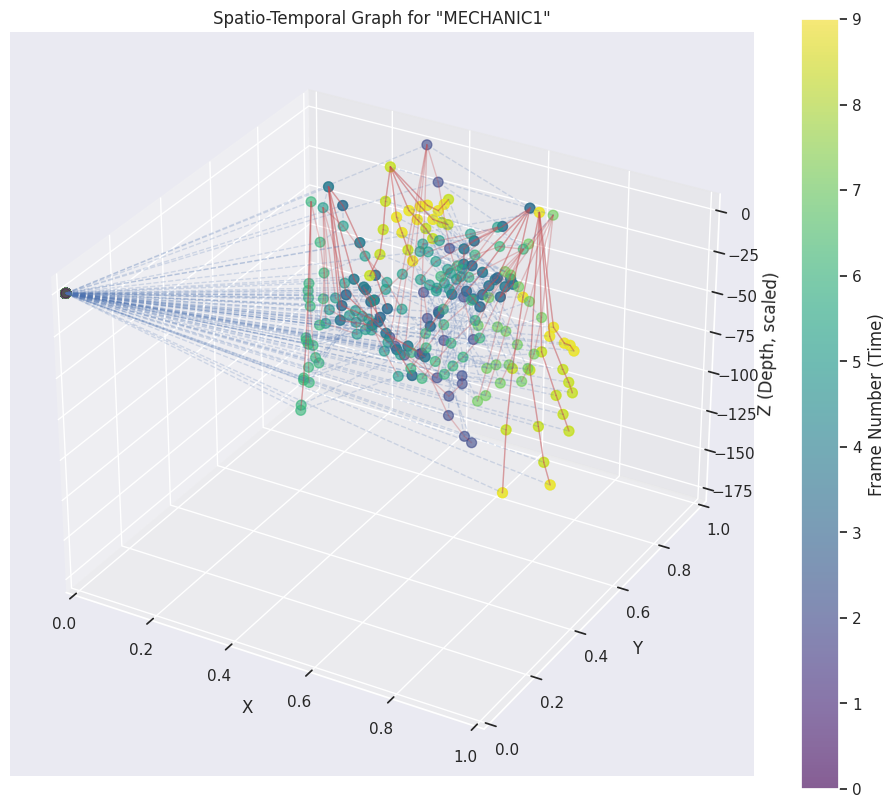

Comppleted...


In [76]:
# 3D Visualization of spatio-temporal graph (with debug)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to visualize one graph in 3D
def visualize_spatio_temporal_graph_3d(features, edges, gloss):
    # Debug: Check features
    # print(f"DEBUG: Features shape: {features.shape}")
    # print(f"DEBUG: Features min/max - x: {features[:, 0].min():.3f}/{features[:, 0].max():.3f}, "
    #       f"y: {features[:, 1].min():.3f}/{features[:, 1].max():.3f}, "
    #       f"z: {features[:, 2].min():.3f}/{features[:, 2].max():.3f}")
    # non_zero_count = np.count_nonzero(features)
    # print(f"DEBUG: Non-zero values in features: {non_zero_count} out of {features.size}")
    
    # Setup 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Features: (420, 3) -> x, y, z
    x = features[:, 0]
    y = features[:, 1]
    z = features[:, 2]
    
    # Amplify z for visibility (MediaPipe z is tiny)
    z = z * 1000  # Scale z by 1000 to make depth visible
    
    # Time dimension (frame number for color)
    time = np.repeat(np.arange(10), 42)
    
    # Plot nodes
    scatter = ax.scatter(x, y, z, c=time, cmap='viridis', s=50, alpha=0.6)
    plt.colorbar(scatter, ax=ax, label='Frame Number (Time)')
    
    # Spatial edges
    for frame_idx in range(10):
        start_idx = frame_idx * 42
        spatial_edges = edges[frame_idx * 40:(frame_idx + 1) * 40]
        for edge in spatial_edges:
            src, dst = edge
            ax.plot([x[src], x[dst]], [y[src], y[dst]], [z[src], z[dst]], 
                    'r-', alpha=0.3, linewidth=1)
    
    # Temporal edges
    temporal_edges = edges[400:]
    for edge in temporal_edges:
        src, dst = edge
        ax.plot([x[src], x[dst]], [y[src], y[dst]], [z[src], z[dst]], 
                'b--', alpha=0.2, linewidth=1)
    
    # Labels and limits
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z (Depth, scaled)')
    ax.set_title(f'Spatio-Temporal Graph for "{gloss}"')
    
    # Set axis limits to ensure visibility
    ax.set_xlim([0, 1])  # x, y are normalized 0-1
    ax.set_ylim([0, 1])
    ax.set_zlim([z.min(), z.max()])
    
    plt.show()

# Load and visualize first graph from dataset
print("Loading...")
for i, graph in enumerate(dataset.take(1)):
    features = graph['features'][0].numpy()  # (420, 3)
    edges = graph['edge_index'][0].numpy()  # (778, 2)
    gloss = graph['gloss'].numpy()[0].decode('utf-8')
    print(f"Visualizing graph for gloss: {gloss}")
    visualize_spatio_temporal_graph_3d(features, edges, gloss)

print("Comppleted...")


Blue lines represent the temporal features across frames in a video <br>
red lines are the edges connecting nodes (joints) within a frame <br>
Different colors represent different frames of the video. For instance :  Violet represents frame 0 whereas yellow presents frame 10

In [68]:
# Interactive 3D Visualization of spatio-temporal graph with Plotly

import plotly.graph_objects as go
import numpy as np

# Function to visualize one graph interactively in 3D
def visualize_spatio_temporal_graph_3d_interactive(features, edges, gloss):
    # Features: (420, 3) -> x, y, z
    x = features[:, 0]
    y = features[:, 1]
    z = features[:, 2] * 1000  # Scale z for visibility
    
    # Time dimension (frame number for color)
    time = np.repeat(np.arange(10), 42)
    
    # Nodes: 3D Scatter
    scatter = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=5, color=time, colorscale='Viridis', opacity=0.6),
        text=[f"Node {i}, Frame {t}" for i, t in enumerate(time)],  # Hover info
        hoverinfo='text'
    )
    
    # Spatial edges: Red lines
    spatial_traces = []
    for frame_idx in range(10):
        start_idx = frame_idx * 42
        spatial_edges = edges[frame_idx * 40:(frame_idx + 1) * 40]
        for edge in spatial_edges:
            src, dst = edge
            spatial_traces.append(go.Scatter3d(
                x=[x[src], x[dst]], y=[y[src], y[dst]], z=[z[src], z[dst]],
                mode='lines',
                line=dict(color='red', width=2),
                opacity=0.3,
                hoverinfo='none'
            ))
    
    # Temporal edges: Blue dashed lines
    temporal_traces = []
    temporal_edges = edges[400:]
    for edge in temporal_edges:
        src, dst = edge
        temporal_traces.append(go.Scatter3d(
            x=[x[src], x[dst]], y=[y[src], y[dst]], z=[z[src], z[dst]],
            mode='lines',
            line=dict(color='blue', width=2, dash='dash'),
            opacity=0.2,
            hoverinfo='none'
        ))
    
    # Combine traces
    data = [scatter] + spatial_traces + temporal_traces
    
    # Layout
    layout = go.Layout(
        title=f'Spatio-Temporal Graph for "{gloss}"',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z (Depth, scaled)',
            xaxis=dict(range=[0, 1]),
            yaxis=dict(range=[0, 1]),
            zaxis=dict(range=[z.min(), z.max()])
        ),
        showlegend=False
    )
    
    # Plot
    fig = go.Figure(data=data, layout=layout)
    fig.show()
    print("Interactive 3D Visualization complete!")

# Load and visualize first graph from dataset
print("Loading graph for interactive 3D visualization...")
for i, graph in enumerate(dataset.take(1)):
    features = graph['features'][0].numpy()  # (420, 3)
    edges = graph['edge_index'][0].numpy()  # (778, 2)
    gloss = graph['gloss'].numpy()[0].decode('utf-8')
    print(f"Visualizing graph for gloss: {gloss}")
    visualize_spatio_temporal_graph_3d_interactive(features, edges, gloss)

Loading graph for interactive 3D visualization...
Visualizing graph for gloss: MECHANIC1


Interactive 3D Visualization complete!


In [180]:
def load_dataset(graphs_metadata_path):
    import tensorflow as tf
    import pandas as pd
    import numpy as np

    # Load the metadata (train_small.csv, test_small.csv, or val_small.csv)
    df = pd.read_csv(graphs_metadata_path)
    print(f"Loaded {len(df)} graphs from {graphs_metadata_path}")

    # Load graph data from .npz files
    def load_graph(row):
        try:
            data = np.load(row['graph_path'])
            features = data['features'].astype(np.float32)  # (420, 3)
            edge_index = data['edge_index'].astype(np.int64)  # (778, 2)
            gloss = data['gloss'].item()  # Extract gloss as string
            if features is None or edge_index is None or gloss is None:
                print(f"Skipping graph with None values: {row['graph_path']}")
                return None
            # Reshape features: (420, 3) -> (1, 42, 10, 3)
            if features.shape == (420, 3):
                features = features.reshape(1, 42, 10, 3)  # 420 = 42 nodes x 10 frames
            else:
                print(f"Unexpected features shape {features.shape} in {row['graph_path']}")
                return None
            # Reshape edge_index: (778, 2) -> (1, 778, 2)
            if edge_index.shape == (778, 2):
                edge_index = np.expand_dims(edge_index, axis=0)  # (1, 778, 2)
            else:
                print(f"Unexpected edge_index shape {edge_index.shape} in {row['graph_path']}")
                return None
            # Data augmentation: Add noise to features
            features += np.random.normal(0, 0.01, features.shape).astype(np.float32)
            if np.any(np.isnan(features)) or np.any(np.isnan(edge_index)):
                print(f"Skipping graph with NaN values: {row['graph_path']}")
                return None
            return {
                'features': features,
                'edge_index': edge_index,
                'gloss': tf.constant([gloss], dtype=tf.string)
            }
        except Exception as e:
            print(f"Error loading graph {row['graph_path']}: {e}")
            return None

    # Filter out None values
    graph_data = [load_graph(row) for _, row in df.iterrows()]
    graph_data = [g for g in graph_data if g is not None]
    print(f"After filtering, {len(graph_data)} valid graphs remain")

    # Debug: Check a few samples
    for i, graph in enumerate(graph_data[:3]):
        print(f"Sample {i+1}: Features shape {graph['features'].shape}, Edge_index shape {graph['edge_index'].shape}, Gloss {graph['gloss']}")

    dataset = tf.data.Dataset.from_generator(
        lambda: (d for d in graph_data),
        output_signature={
            'features': tf.TensorSpec(shape=(1, 42, 10, 3), dtype=tf.float32),
            'edge_index': tf.TensorSpec(shape=(1, 778, 2), dtype=tf.int64),
            'gloss': tf.TensorSpec(shape=(1,), dtype=tf.string)
        }
    ).cache()

    print("Checking dataset contents...")
    for i, graph in enumerate(dataset.take(3)):
        print(f"Dataset sample {i+1}: Features shape {graph['features'].shape}, Edge_index shape {graph['edge_index'].shape}, Gloss {graph['gloss'].numpy()[0].decode('utf-8')}")

    return dataset

In [181]:
def build_feature_learner(hidden_dim=64):
    import tensorflow as tf
    from tensorflow.keras import layers

    class GATLayer(tf.keras.layers.Layer):
        def __init__(self, output_dim, num_heads=4):
            super(GATLayer, self).__init__()
            self.output_dim = output_dim
            self.num_heads = num_heads
            self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=output_dim // num_heads, dropout=0.1)
            self.dense = layers.Dense(output_dim, kernel_regularizer=tf.keras.regularizers.l2(0.01))
        
        def build(self, input_shape):
            self.dense.build(input_shape)
            attention_shape = (None, input_shape[2], self.output_dim)  # (batch, 10, output_dim)
            self.attn.build(
                query_shape=attention_shape,
                value_shape=attention_shape,
                key_shape=attention_shape
            )
            self.built = True
        
        def call(self, inputs, edge_index):
            # inputs: (42, 10, 3)
            x = self.dense(inputs)  # (42, 10, output_dim)
            # Transpose to (10, 42, output_dim) to treat frames as batch
            x = tf.transpose(x, [1, 0, 2])  # (10, 42, output_dim)
            # Squeeze edge_index: (1, 778, 2) -> (778, 2)
            edge_index_squeezed = tf.squeeze(edge_index, axis=0)  # (778, 2)
            # Ensure indices are within bounds [0, 42)
            edge_index_clipped = tf.clip_by_value(edge_index_squeezed, 0, 41)
            # Remove duplicate indices
            edge_index_flat, unique_indices = tf.unique(tf.reshape(edge_index_clipped, [-1]))
            edge_index_flat = tf.reshape(edge_index_flat, [-1, 2])
            values = tf.ones(tf.shape(edge_index_flat)[0], dtype=tf.float32)
            adj = tf.sparse.SparseTensor(
                indices=tf.cast(edge_index_flat, tf.int64),
                values=values,
                dense_shape=[42, 42]
            )
            adj = tf.sparse.reorder(adj)
            adj = tf.sparse.to_dense(adj)  # (42, 42)
            # Attention mask: (batch_size, num_heads, query_length, key_length)
            # batch_size = 10 (frames), query_length = key_length = 42 (nodes)
            batch_size = tf.shape(x)[0]  # 10 frames
            adj = tf.expand_dims(adj, 0)  # (1, 42, 42)
            adj = tf.expand_dims(adj, 0)  # (1, 1, 42, 42)
            adj = tf.tile(adj, [batch_size, self.num_heads, 1, 1])  # (10, 4, 42, 42)
            # Apply attention over nodes for each frame
            h = self.attn(x, x, attention_mask=adj)  # (10, 42, output_dim)
            # Transpose back to (42, 10, output_dim)
            h = tf.transpose(h, [1, 0, 2])  # (42, 10, output_dim)
            return h

    class MambaLayer(tf.keras.layers.Layer):
        def __init__(self, hidden_dim):
            super(MambaLayer, self).__init__()
            self.hidden_dim = hidden_dim
            self.dense = layers.Dense(hidden_dim)
            self.gru = layers.GRU(hidden_dim, return_sequences=True)
        
        def build(self, input_shape):
            self.dense.build(input_shape)
            self.gru.build((None, input_shape[1], self.hidden_dim))
            self.built = True
        
        def call(self, inputs):
            x = self.dense(inputs)  # (batch, 10, hidden_dim)
            return self.gru(x)  # (batch, 10, hidden_dim)

    class FeatureLearner(tf.keras.Model):
        def __init__(self, hidden_dim):
            super(FeatureLearner, self).__init__()
            self.hidden_dim = hidden_dim
            self.gat = GATLayer(hidden_dim)
            self.mamba = MambaLayer(hidden_dim)
            self.pool = layers.GlobalAveragePooling1D()
            self.dense = layers.Dense(hidden_dim, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))
        
        def build(self, input_shape):
            self.gat.build((None, 42, 10, 3))
            mamba_input_shape = (None, 10, self.hidden_dim)
            self.mamba.build(mamba_input_shape)
            self.pool.build((None, 10, self.hidden_dim))
            self.dense.build((None, self.hidden_dim))
            self.built = True

        def call(self, inputs):
            x = tf.squeeze(inputs['features'], axis=0)  # (42, 10, 3)
            edge_index = inputs['edge_index']
            # Apply GAT to process spatial graph structure
            h = self.gat(x, edge_index)  # (42, 10, hidden_dim)
            # Transpose to (10, 42, hidden_dim) for temporal processing
            h = tf.transpose(h, [1, 0, 2])
            # Apply Mamba to process temporal dimension
            h = self.mamba(h)  # (10, 42, hidden_dim)
            # Pool over time steps
            h = self.pool(h)  # (42, hidden_dim)
            # Pool over nodes
            h = tf.reduce_mean(h, axis=0)  # (hidden_dim,)
            # Add batch dimension for Dense layer
            h = tf.expand_dims(h, axis=0)  # (1, hidden_dim)
            # Final dense layer
            h = self.dense(h)  # (1, hidden_dim)
            # Remove batch dimension for output
            h = tf.squeeze(h, axis=0)  # (hidden_dim,)
            return h

    return FeatureLearner(hidden_dim)

In [182]:
# Test the GAT + Mamba feature learner
dataset = load_dataset("/kaggle/working/graphs_tf/graphs_metadata.csv")
model = build_feature_learner(hidden_dim=64)

# Process a few samples
for i, graph in enumerate(dataset.take(3)):
    features = model(graph)
    print(f"Sample {i+1}: Extracted features shape {features.shape}")

Loaded 217 graphs from /kaggle/working/graphs_tf/graphs_metadata.csv
After filtering, 217 valid graphs remain
Sample 1: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss [b'DOG1']
Sample 2: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss [b'DOG1']
Sample 3: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss [b'DOG1']
Checking dataset contents...
Dataset sample 1: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss DOG1
Dataset sample 2: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss DOG1
Dataset sample 3: Features shape (1, 42, 10, 3), Edge_index shape (1, 778, 2), Gloss DOG1
Sample 1: Extracted features shape (64,)
Sample 2: Extracted features shape (64,)
Sample 3: Extracted features shape (64,)


In [183]:
# Classify and Test
def train_and_classify(train_path, val_path, test_path, hidden_dim=64, num_classes=23, epochs=5):
    import tensorflow as tf
    import pandas as pd
    import numpy as np
    import os

    gloss_to_label = {
        "DOG1": 0, "BITE1": 1, "BASKETBALL1": 2, "DEAF1": 3, "PARTY1": 4,
        "DARK1": 5, "BEE1": 6, "FOREIGNER1": 7, "SHAVE1": 8, "HOSPITAL1": 9,
        "PATIENT2": 10, "ROCKINGCHAIR1": 11, "MECHANIC1": 12, "WHATFOR1": 13,
        "BELT1": 14, "FINE1": 15, "NIGHT1": 16, "CHRISTMAS1": 17, "BREAKFAST1": 18,
        "DEMAND1": 19, "MOVIE1": 20, "EAT1": 21, "ELEVATOR1": 22
    }

    # Load graphs_metadata.csv to create a mapping from video_id to graph_path
    graphs_metadata_path = "/kaggle/working/graphs_tf/graphs_metadata.csv"
    graphs_df = pd.read_csv(graphs_metadata_path)
    print(f"Loaded {len(graphs_df)} entries from {graphs_metadata_path}")
    graphs_df['video_id'] = graphs_df['graph_path'].apply(lambda x: x.split('/')[-1].split('_graph.npz')[0])
    video_to_graph_path = dict(zip(graphs_df['video_id'], graphs_df['graph_path']))

    # Function to add graph_path to a small subset CSV and save a temporary CSV
    def add_graph_path_and_save(csv_path, output_path):
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} entries from {csv_path}")
        print("Columns in the CSV:", df.columns.tolist())
        
        # Add graph_path by mapping video_id
        df['graph_path'] = df['video_id'].map(video_to_graph_path)
        if df['graph_path'].isnull().any():
            print(f"Warning: Some video_ids in {csv_path} did not match any graph_path")
            print("Unmatched video_ids:", df[df['graph_path'].isnull()]['video_id'].tolist())
            df = df.dropna(subset=['graph_path'])
        
        print(f"After adding graph_path, {len(df)} entries remain in {csv_path}")
        
        # Save to a temporary CSV
        df.to_csv(output_path, index=False)
        print(f"Saved temporary CSV with graph_path to {output_path}")
        return output_path

    # Create temporary CSVs with graph_path
    temp_train_path = "/kaggle/working/graphs_tf/temp_train_small.csv"
    temp_val_path = "/kaggle/working/graphs_tf/temp_val_small.csv"
    temp_test_path = "/kaggle/working/graphs_tf/temp_test_small.csv"

    add_graph_path_and_save(train_path, temp_train_path)
    add_graph_path_and_save(val_path, temp_val_path)
    add_graph_path_and_save(test_path, temp_test_path)

    def prepare_data(graph):
        gloss = graph['gloss'][0]
        gloss = tf.strings.strip(gloss)
        keys = tf.constant(list(gloss_to_label.keys()), dtype=tf.string)
        values = tf.constant(list(gloss_to_label.values()), dtype=tf.int32)
        table = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(keys, values),
            default_value=22  # Default label if gloss not found
        )
        label = table.lookup(gloss)
        return graph, label

    # Load datasets using the temporary CSVs
    train_dataset = load_dataset(temp_train_path).map(prepare_data).batch(1)
    val_dataset = load_dataset(temp_val_path).map(prepare_data).batch(1)
    test_dataset = load_dataset(temp_test_path).map(prepare_data).batch(1)

    # Build model with classification head
    model = build_feature_learner(hidden_dim)
    inputs = tf.keras.Input(shape=(hidden_dim,))
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(inputs)
    classifier = tf.keras.Model(inputs, outputs)

    # Compile and train
    full_model = tf.keras.Sequential([model, classifier])
    full_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    full_model.fit(train_dataset, validation_data=val_dataset, epochs=epochs, verbose=1)

    # Test
    gloss_map = {v: k for k, v in gloss_to_label.items()}
    predictions = []
    for graph in test_dataset.take(3):
        features = model(graph)
        logits = classifier(features)
        action = tf.argmax(logits, axis=0).numpy()
        predicted_gloss = gloss_map.get(action, "UNKNOWN")
        true_gloss = graph['gloss'].numpy()[0].decode('utf-8')
        predictions.append((predicted_gloss, true_gloss))
    return predictions

In [174]:
train_path

'/kaggle/working/graphs_tf/train_small.csv'

In [ ]:
train_path = "/kaggle/working/graphs_tf/train_small.csv"
val_path = "/kaggle/working/graphs_tf/val_small.csv"
test_path = "/kaggle/working/graphs_tf/test_small.csv"
predictions = train_and_classify(train_path, val_path, test_path)
for predicted_gloss, true_gloss in predictions:
    print(f"Predicted: {predicted_gloss}, True: {true_gloss}")

Loaded 217 entries from /kaggle/working/graphs_tf/graphs_metadata.csv
Loaded 217 entries from /kaggle/working/graphs_tf/train_small.csv
Columns in the CSV: ['p_id', 'video_id', 'gloss', 'code']
After adding graph_path, 217 entries remain in /kaggle/working/graphs_tf/train_small.csv
Saved temporary CSV with graph_path to /kaggle/working/graphs_tf/temp_train_small.csv
Loaded 47 entries from /kaggle/working/graphs_tf/val_small.csv
Columns in the CSV: ['p_id', 'video_id', 'gloss', 'code']
Unmatched video_ids: ['3250233036968666-DOG.mp4', '9692444989436564-DOG.mp4', '8615822021106332-DOG.mp4', '7432967051023693-BITE.mp4', '45986851425089204-BITE.mp4', '9595255203933857-BITE.mp4', '4747623892063422-BASKETBALL.mp4', '9432574110287932-seedBASKETBALL.mp4', '7322377994548119-DEAF.mp4', '14415908988995363-DEAF.mp4', '1920154326917336-PARTY.mp4', '8706611505389534-PARTY.mp4', '5156194365351785-DARK.mp4', '08763437833459409-DARK.mp4', '6942834524009942-BEE.mp4', '21912688008400893-BEE.mp4', '980020